**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

%matplotlib inline

In [4]:
df = pd.read_csv('/content/train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Dataset Information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

**Missing Values Analysis**

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Visualize Missing Values**

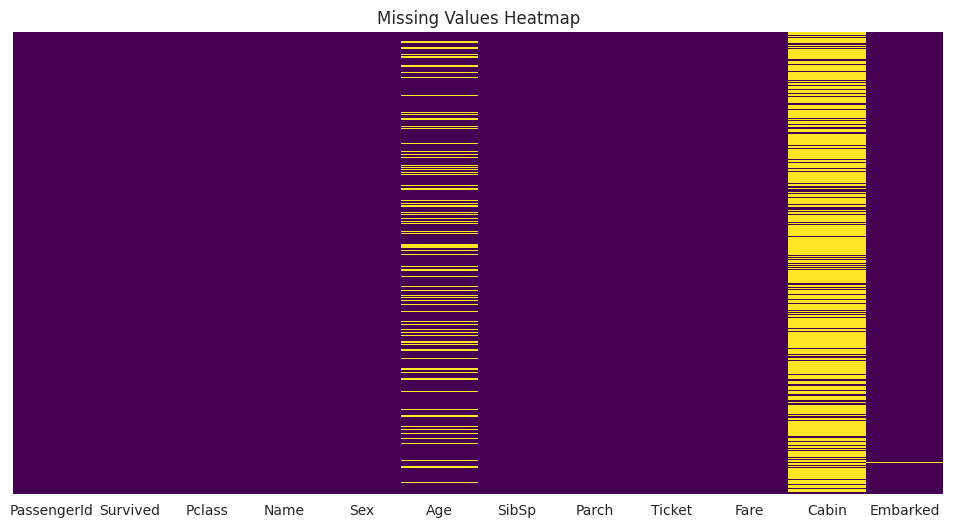

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cmap='viridis',
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

**Data Cleaning**

In [ ]:
df['Age'].fillna(
    df['Age'].median(),
    inplace=True
)

In [ ]:
df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)

In [13]:
(df['Cabin'].isnull().sum()/len(df))*100

np.float64(77.10437710437711)

In [14]:
df.drop(
    'Cabin',
    axis=1,
    inplace=True
)

**Verify Missing Values**

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Univariate Analysis: Survival Distribution**

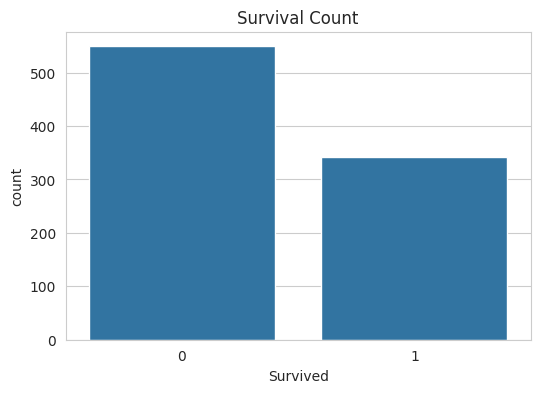

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Count")
plt.show()

**Gender Distribution**

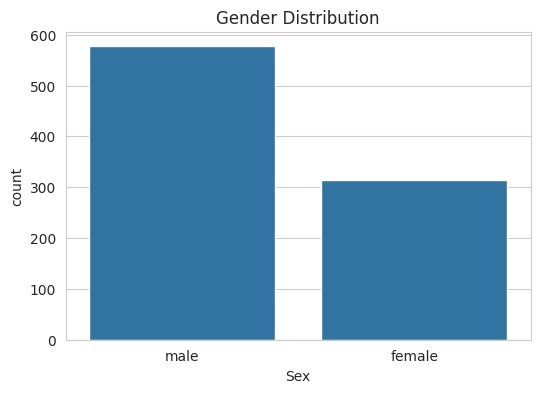

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    data=df
)

plt.title("Gender Distribution")
plt.show()

**Passenger Class Distribution**

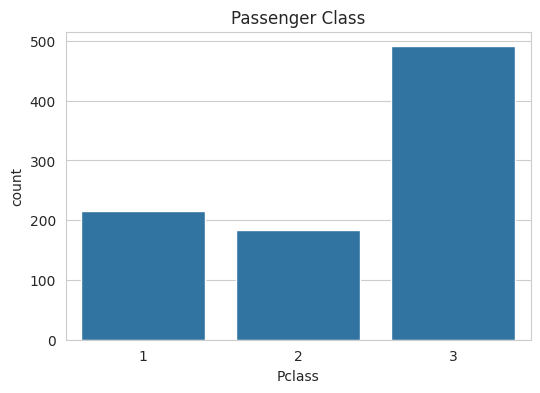

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    data=df
)

plt.title("Passenger Class")
plt.show()

**Age Distribution**

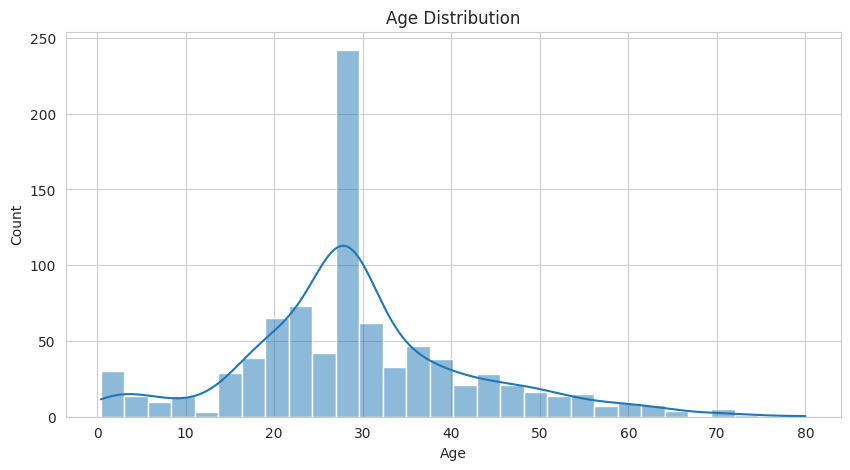

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

**Fare Distribution**

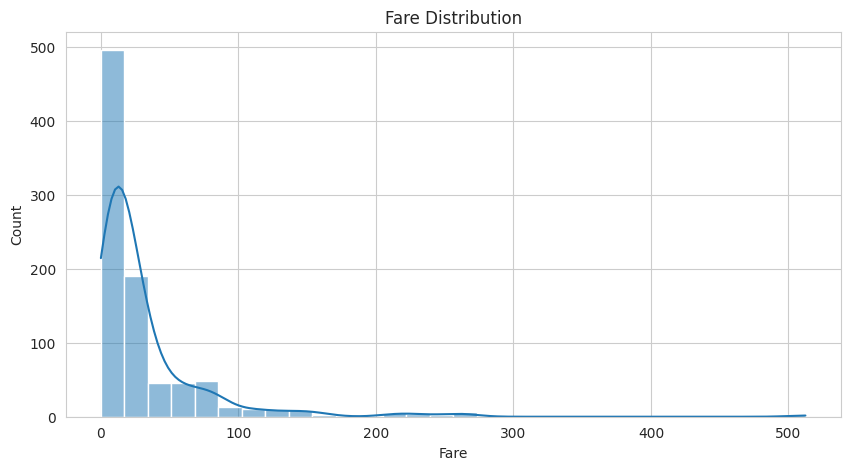

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

**Bivariate Analysis: Survival vs Gender**

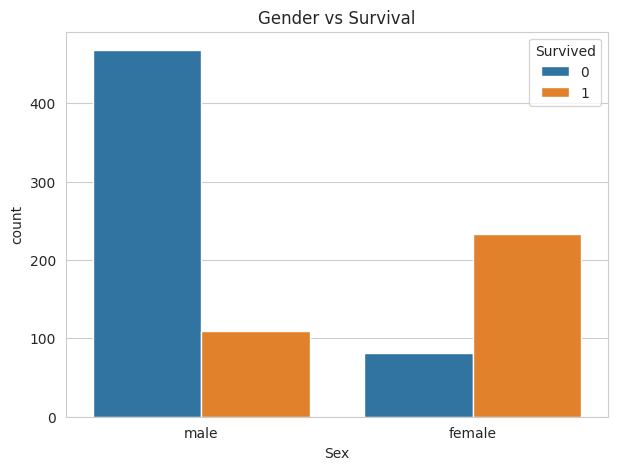

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Gender vs Survival")
plt.show()

**Survival vs Passenger Class**

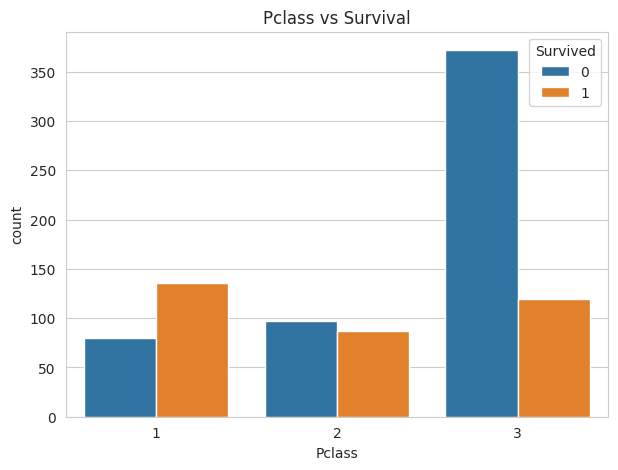

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Pclass vs Survival")
plt.show()

**Survival vs Age**

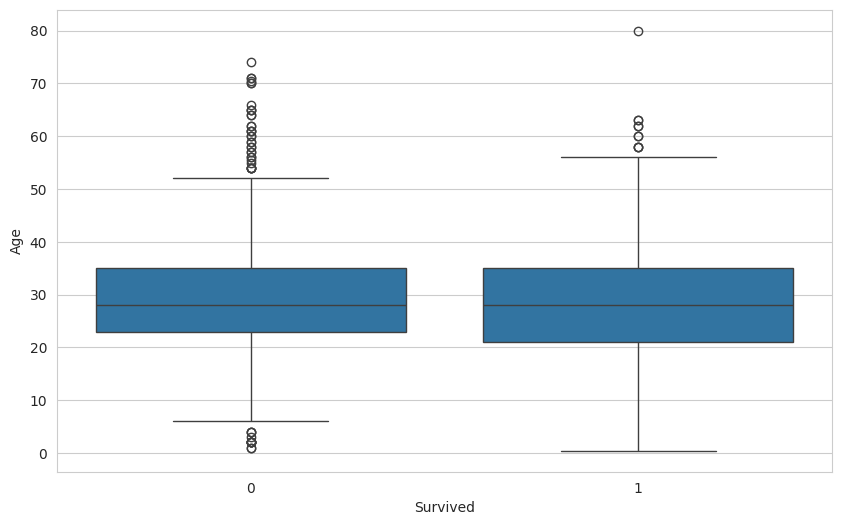

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Survived',
    y='Age',
    data=df
)

plt.show()

**Feature Engineering**

In [27]:
df['FamilySize'] = (
    df['SibSp'] +
    df['Parch'] + 1
)

df[['FamilySize']].head()

,FamilySize
0,2
1,2
2,1
3,2
4,1


**Family Size Distribution**

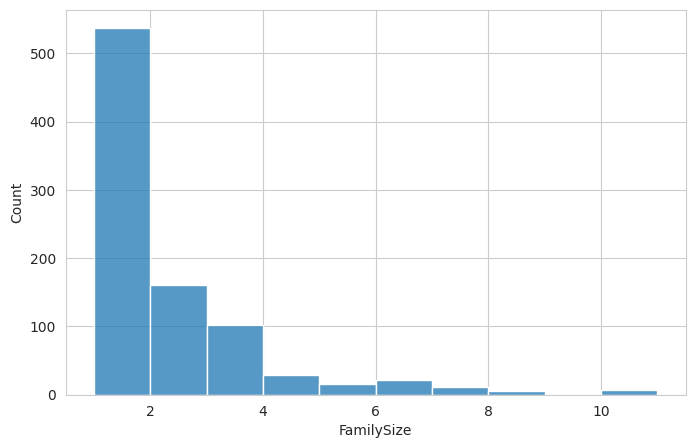

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['FamilySize'],
    bins=10
)

plt.show()

**Survival vs Family Size**

<Axes: xlabel='Survived', ylabel='FamilySize'>

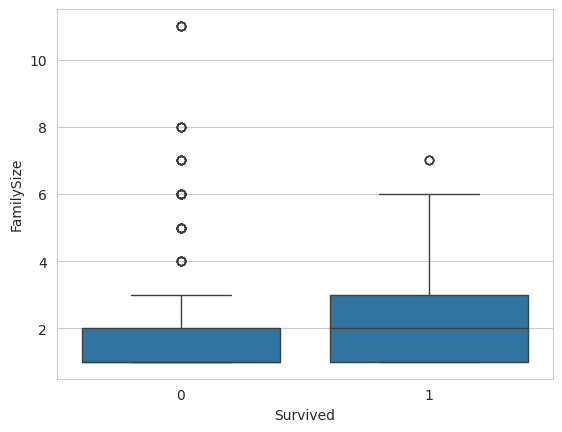

In [29]:
sns.boxplot(
    x='Survived',
    y='FamilySize',
    data=df
)

**Correlation Matrix**

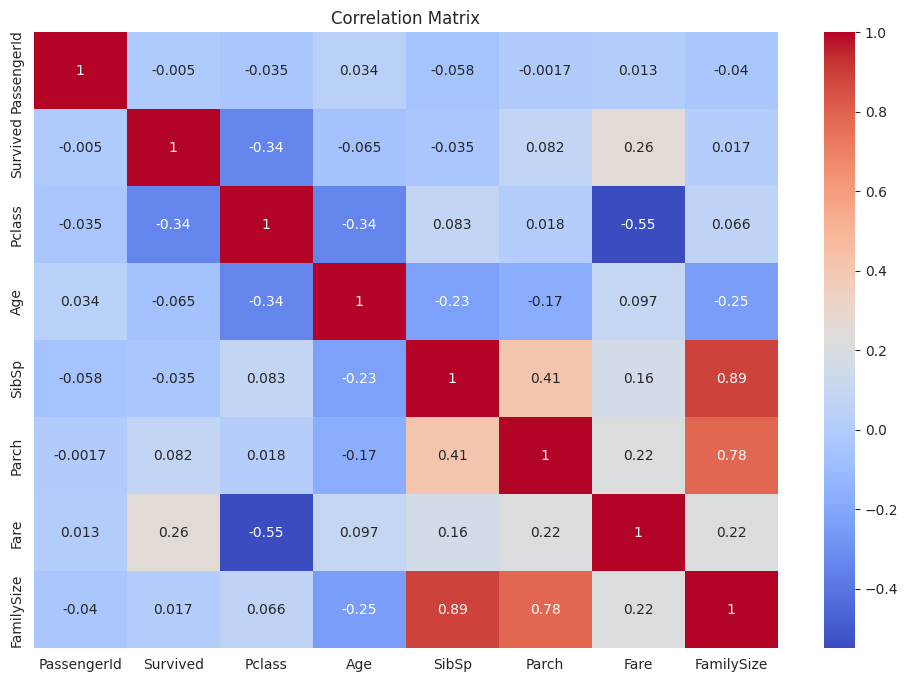

In [30]:
corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

___________________________________________________________
**Top Insights**

INSIGHT 1:
Female passengers had much higher survival rates.

INSIGHT 2:
First-class passengers survived significantly more.

INSIGHT 3:
Passengers paying higher fares were more likely to survive.

INSIGHT 4:
Children had higher survival rates.

INSIGHT 5:
Passenger class strongly influenced survival.

INSIGHT 6:
Most passengers were aged between 20–40 years.

INSIGHT 7:
Fare distribution contains extreme outliers.

**Final Conclusion**

The Titanic dataset analysis shows that gender, passenger class, age, and fare were important factors affecting survival.

Women and first-class passengers had significantly better chances of survival. Fare and passenger class showed strong relationships with survival probability. Most passengers were young adults, and the dataset contained substantial missing values that were successfully cleaned before analysis.